In [1]:
#Use kernel 3.7.9 python
#!pip install pandas
import pandas as pd
demand_path = "data/real_data_excel/production_data/COOIS_Released_Prod_Orders.csv"
df = pd.read_csv("../"+demand_path)
df.head()

,Order,Material Number,Material description,Order quantity (GMEIN),Basic start date,Basic finish date,System Status
0,100033364,S9992431,"SUB 1/8 NBK, Clinic, Module 1, Medicines",14,2025-03-03,2025-03-07,REL PRC BCRQ MACM SETC
1,100034881,S9991123,SUB 3/5 f.S9901026 IEHK2017 part 1,58,2025-03-17,2025-03-21,REL PRC BCRQ MACM SETC
2,100035124,S9992442,"SUB 2/3 NBK, Clinic,Module 2,Consumables",5,2025-03-14,2025-03-21,REL PRC BCRQ MACM SETC
3,100034003,S9901042,"IEHK 2024,Basic Equipment UNIT",800,2025-03-24,2025-03-28,REL PRC BCRQ MANC SETC
4,100034017,S9901042,"IEHK 2024,Basic Equipment UNIT",800,2025-03-24,2025-03-28,REL PRC BCRQ MANC SETC


In [2]:
df.dtypes

Order                      int64
Material Number           object
Material description      object
Order quantity (GMEIN)     int64
Basic start date          object
Basic finish date         object
System Status             object
dtype: object

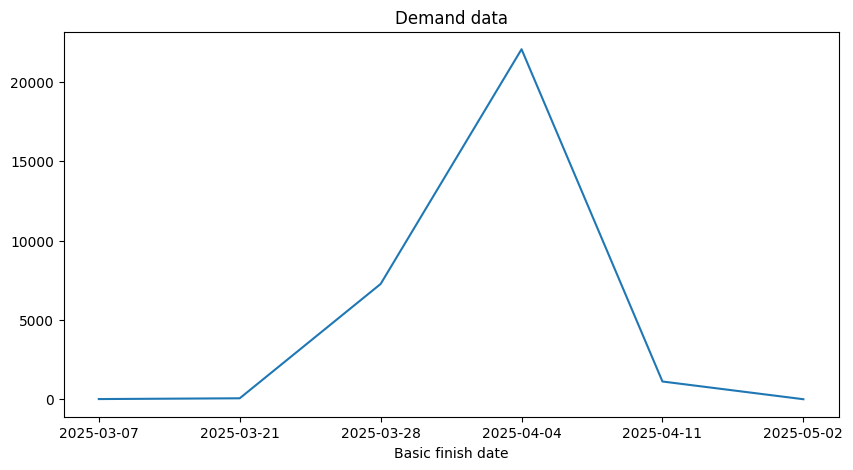

In [3]:
#Demand data
import matplotlib.pyplot as plt
pure_quant = df.groupby('Basic finish date').sum()['Order quantity (GMEIN)']
plt.figure()
plt.title('Demand data')
pure_quant.plot(kind='line', figsize=(10, 5))
plt.show()


- demand viz / date
- resource viz
- inventory capa viz
- available hr viz

In [4]:
data_path = "../data/real_data_excel/production_data/"
human_resource_per_kit =  "Kits__Calculation.csv"

In [5]:
import pandas as pd

kit_resource_info = pd.read_csv(data_path + human_resource_per_kit, header=0, skiprows=[0])
kit_resource_info.head()




,Kit,Description,Kit per day,Humanizer,UNICEF staff,Paid work hours per day,Humanizer hours,UNICEF hours,Total Hours,Hourly rate humanizer staff in USD,Hourly rate UNICEF staff in USD,Cost for humanizer for 800 kits,Cost for UNICEF staff for 800 kits,Total cost,Hours per kit,Cost for subkit/prepack/Kits
0,S9935011,"School-in-a-carton,40 students, 2016",800,11.0,2.0,7.5,82.5,15.0,97.5,25.87,30,2134.275,450,2584.275,0.121875,3.230344
1,S9999991,Education prepack 2 for new SIB (I),800,5.0,1.0,7.5,37.5,7.5,45.0,25.87,30,970.125,225,1195.125,0.056250,1.493906
2,S9999990,Education prepack 1 for new SIB (I),800,5.0,1.0,7.5,37.5,7.5,45.0,25.87,30,970.125,225,1195.125,0.056250,1.493906
3,S9935019,"School-in-a-bag kit,40 student,1 teacher",800,9.0,2.0,7.5,67.5,15.0,82.5,25.87,30,1746.225,450,2196.225,0.103125,2.745281
4,S9999933,Prepack 1/1 School in a Bag S9935019,800,3.0,1.0,7.5,22.5,7.5,30.0,25.87,30,582.075,225,807.075,0.037500,1.008844


In [6]:
demand = pd.read_csv(data_path + "COOIS_Released_Prod_Orders.csv")
demand.head()
demand['Material Number'] =demand['Material Number'].str.strip()
kit_resource_info['Kit'] = kit_resource_info['Kit'].str.strip()
df_merged = pd.merge(demand[['Material Number', 'Order quantity (GMEIN)','Basic finish date']], kit_resource_info, left_on = 'Material Number', right_on = 'Kit', how = 'left')
df_merged.head()

,Material Number,Order quantity (GMEIN),Basic finish date,Kit,Description,Kit per day,Humanizer,UNICEF staff,Paid work hours per day,Humanizer hours,UNICEF hours,Total Hours,Hourly rate humanizer staff in USD,Hourly rate UNICEF staff in USD,Cost for humanizer for 800 kits,Cost for UNICEF staff for 800 kits,Total cost,Hours per kit,Cost for subkit/prepack/Kits
0,S9992431,14,2025-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S9991123,58,2025-03-21,S9991123,SUB 3/5 f.S9901026 IEHK2017 part 1,800.0,9.0,2.0,7.5,67.5,15.0,82.5,25.87,30.0,1746.225,450.0,2196.225,0.103125,2.745281
2,S9992442,5,2025-03-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S9901042,800,2025-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S9901042,800,2025-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
kit_resource_info.columns
column_name_cleaning_kit_resource_info = {
    'Humanizer': 'Number of humanizer to finish 800 in 7.5 hours',
    'UNICEF staff' : 'Number of UNICEF staff to finish 800 in 7.5 hours'}

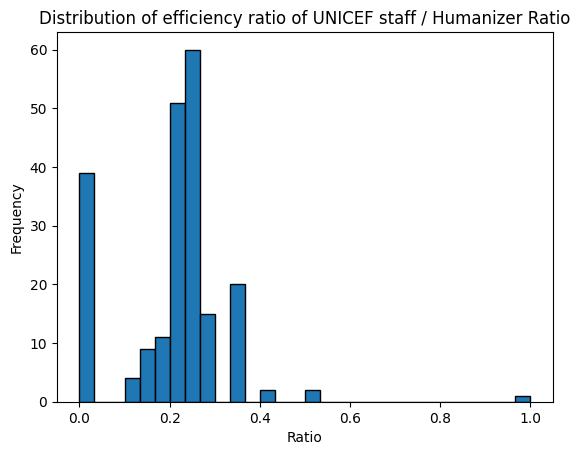

In [8]:
#Is the information in the kit_resource_info correct? How is it calculated? Can we discuss how it is calculated?
import matplotlib.pyplot as plt

ratio = kit_resource_info['UNICEF staff'] / kit_resource_info['Humanizer']

plt.hist(ratio, bins=30, edgecolor='black')
plt.title("Distribution of efficiency ratio of UNICEF staff / Humanizer Ratio")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()
#This data ->  (Lack of confidence)

In [9]:
common_values = set(demand['Material Number']).intersection(set(kit_resource_info['Kit']))
only_in_kit = set(kit_resource_info['Kit']) - set(demand['Material Number'])
only_in_demand = set(demand['Material Number']) - set(kit_resource_info['Kit'])
print(
    f"Common values: {common_values}\n"
    f"Only in kit: {only_in_kit}\n"
    f"Only in demand: {only_in_demand}"
)

#problem1  - some of id only in demand
#We can set up database RDB shape - Let's see where the data is from
#Inconsistent data naming

Common values: {'S9999133', 'S9991125', 'S9999143', 'S9991225', 'S9991123', 'S9999137', 'S9999945', 'S9999125', 'S9999124', 'S9999933', 'S9935084', 'S9999979', 'S9935090', 'S9999987', 'S9999986', 'S9991229', 'S9999994', 'S9910004', 'S9991222', 'S9991228', 'S9999974'}
Only in kit: {'S9991122', 'S9999923', 'S9993739', 'S9990034', 'S9902221', 'S9999882', 'S9998281', 'S9997733', 'S9997735', 'S9986710', 'S9935100', 'S9999592', 'S9935011', 'S9993730', 'S9901030', 'S9999128', 'S9906801', 'S9996716', 'S9999884', 'S9993843', 'S9906712', 'S9901024', 'S9935019', 'S9986723', 'S9994733', 'S9999995', 'S9935095', 'S9999862', 'S9999898', 'S9997737', 'S9994738', 'S9990041', 'S9991124', 'S9999842', 'S9993734', 'S9908402', 'S9901022', 'S9999502', 'S9999494', 'S9986722', 'S9910002', 'S9910006', 'S9906734', 'S9999132', 'S9993736', 'S9996714', 'S9903005', 'S9998837', 'S9999591', 'S9994737', 'S9999924', 'S9906710', 'S9901023', 'S9996710', 'S9986711', 'S9999136', 'S9910005', 'S9991321', 'S9997734', 'S9999841'

In [10]:
df_merged['Basic finish date'] = pd.to_datetime(df_merged['Basic finish date'])


In [11]:
kit_resource_info['humanizer_per_hour_production'] = 800 / (kit_resource_info['Humanizer'] * kit_resource_info['Paid work hours per day'])
kit_resource_info['unicef_per_hour_production'] = 800 / (kit_resource_info['UNICEF staff'] * kit_resource_info['Paid work hours per day'])

In [12]:
df_merged['required_humanizer'] = df_merged['Order quantity (GMEIN)'] / df_merged['humanizer_per_hour_production']
df_merged['required_unicef'] = df_merged['Order quantity (GMEIN)'] / df_merged['unicef_per_hour_production']
df_merged.head()

KeyError: 'humanizer_per_hour_production'

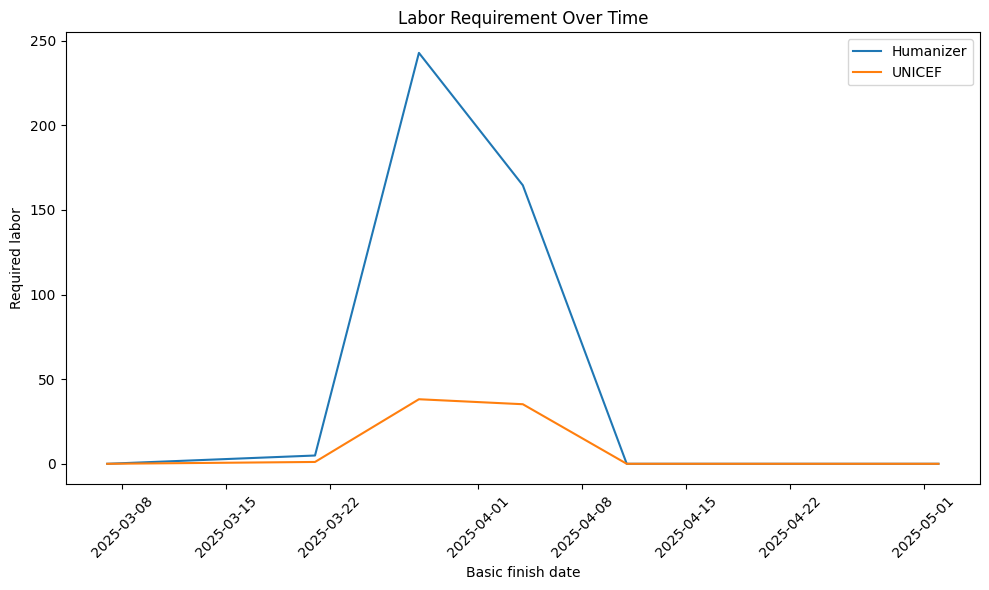

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

grouped = df_merged.groupby('Basic finish date').sum()

plt.plot(grouped.index, grouped['required_humanizer'], label='Humanizer')
plt.plot(grouped.index, grouped['required_unicef'], label='UNICEF')

plt.xlabel('Basic finish date')
plt.ylabel('Required labor')
plt.title('Labor Requirement Over Time')
plt.legend()
plt.xticks(rotation=45)  # 날짜가 겹치지 않게 회전
plt.tight_layout()

plt.show()

### Available UNICEF Staff (Fixed resource)

In [13]:
available_unicef_staff = 7

In [14]:
shortfall = (grouped['required_unicef'] - available_unicef_staff).clip(lower=0)
plt.figure()
plt.title('Shortfall of UNICEF staff')
shortfall.plot(kind='line', xlabel='Basic finish date', ylabel='Shortfall')
plt.show()


NameError: name 'grouped' is not defined

# Bottleneck due to Inventory

In [15]:
workcenter_capa = pd.read_csv(data_path+"Work_Centre_Capacity.csv")
workcenter_capa

capacity_info = workcenter_capa['Capacity Campus 2'].str.extract(r'(?P<capacity>\d+)\s*(?P<unit>\w+)')
capacity_info['capacity'] = capacity_info['capacity'].astype(float)
workcenter_capa['Per hour capacity'] = capacity_info['capacity']
workcenter_capa['Unit'] = capacity_info['unit']
workcenter_capa[['Work Area', 'Per hour capacity', 'Unit']]

#Need to clarify on the data (work area naming)
column_pair = {'Short / flex lines':'SHORT_LINE', 'Long lines':'LONG_LINE'}
workcenter_capa['Work Area'] = workcenter_capa['Work Area'].replace(column_pair)
workcenter_capa[['Work Area', 'Per hour capacity', 'Unit']]

,Work Area,Per hour capacity,Unit
0,Receiving,73.0,pallets
1,Shipping,94.0,pallets
2,Depalletizing station,NaN,NaN
3,Pre-pack lines,300.0,cartons
4,Pre-pick station,NaN,NaN
5,LONG_LINE,300.0,cartons
6,SHORT_LINE,54.0,pallets
7,NaN,NaN,NaN
8,To not be considered currently,NaN,NaN


In [16]:
#Need info on how many work area we have

supply_unit_info=pd.DataFrame([
    {"Unit": "pallets", "Per_hour_capacity_fake": 100},
    {"Unit": "cartons", "Per_hour_capacity_fake": 1000}])

workcenter_capa['Total_line_count_fake'] = [1, 2, 3, 4, 5, 6, 7, "Nan", "Nan"]
workcenter_capa

,Work Area,Capacity Campus 2,Pallets per hour,Cartons per hour,Per hour capacity,Unit,Total_line_count_fake
0,Receiving,73 pallets per hour,73.0,NaN,73.0,pallets,1
1,Shipping,94 pallets per hour,94.0,NaN,94.0,pallets,2
2,Depalletizing station,NaN,NaN,NaN,NaN,NaN,3
3,Pre-pack lines,300 cartons per hour,NaN,300.0,300.0,cartons,4
4,Pre-pick station,NaN,NaN,NaN,NaN,NaN,5
5,LONG_LINE,300 cartons per hour,NaN,300.0,300.0,cartons,6
6,SHORT_LINE,54 pallets per hour,54.0,NaN,54.0,pallets,7
7,NaN,NaN,NaN,NaN,NaN,NaN,Nan
8,To not be considered currently,NaN,NaN,NaN,NaN,NaN,Nan


In [17]:
import pandas as pd

Material_master = pd.read_csv(data_path + "Material_Master_WMS.csv")
Material_master.head()

Material_master.columns

Material_master['Material Number'] = Material_master['Material Number'].str.strip()
Material_master['KIT Routing'].unique()

array(['SHORT_LINE', 'LONG_LINE', 'MINILOAD', 'VIRTUAL_PACKING',
       'BAGGING_LINE'], dtype=object)

In [18]:
#Max product per day due to work center capacity => Number of days required minimum => labor